In [ ]:
# Q1
M <- as.matrix(read.csv("co_occur.csv", header = FALSE))
dict <- readLines("dictionary.txt")

print(dim(M))
print(length(dict))
print(dict[1:10])
print(round(M[1:5, 1:5], 3))

# check word index
words_to_check <- c("the", "of", "in", "and", "to")
idx <- match(words_to_check, dict)
print(data.frame(word = words_to_check, index = idx))

Warning message in readLines("dictionary.txt"):
“incomplete final line found on 'dictionary.txt'”


[1] 10000 10000
[1] 10000
 [1] "the" "of"  "in"  "and" "to"  "was" "is"  "for" "on"  "as" 
           V1       V2       V3      V4      V5
[1,]        0 24637000 13531000 6871500 7348100
[2,] 24637000        0  1388900 2305900  495270
[3,] 13531000  1388900        0 2761000 1095500
[4,]  6871500  2305900  2761000       0 1272200
[5,]  7348100   495270  1095500 1272200       0
  word index
1  the     1
2   of     2
3   in     3
4  and     4
5   to     5


In [ ]:
# Q2
install.packages("irlba", repos = "https://cloud.r-project.org")
library(irlba)
# normalized
M_tilde <- log1p(M)

cat("Dimension of M_tilde:\n")
print(dim(M_tilde))

# compute the top 100
svd_out <- irlba(M_tilde, nv = 50, nu = 50)

U <- svd_out$u
D <- svd_out$d
V <- svd_out$v

cat("\nDimensions of U, D, V:\n")
print(dim(U))
print(length(D))
print(dim(V))

cat("\nFirst 20 singular values:\n")
print(round(D[1:20], 4))

# save
saveRDS(list(U = U, D = D, V = V), "svd_top100.rds")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Dimension of M_tilde:
[1] 10000 10000

Dimensions of U, D, V:
[1] 10000    50
[1] 50
[1] 10000    50

First 20 singular values:
 [1] 14299.7431  2864.8156  2682.6538  1745.5549  1528.4172  1308.7619
 [7]  1185.7405  1128.0526  1102.5571   956.3077   916.0537   853.3530
[13]   820.3448   773.6605   719.6944   701.5217   678.1840   642.6452
[19]   617.5387   594.8363


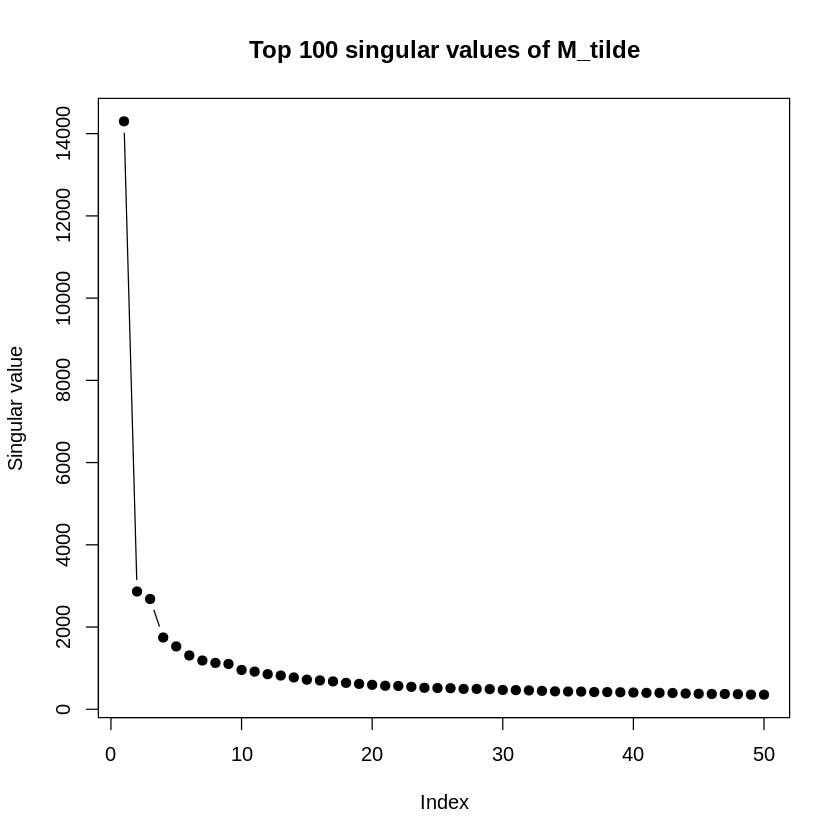

In [ ]:
# plot
plot(
  D,
  type = "b",
  pch = 19,
  xlab = "Index",
  ylab = "Singular value",
  main = "Top 100 singular values of M_tilde"
)

In [ ]:
# Q3

# Data recheck
dict <- readLines("dictionary.txt")
svd_saved <- readRDS("svd_top100.rds")
V <- svd_saved$V
print(dim(V))
print(length(D))

inspect_vector <- function(V, dict, i, top_n = 10) {
  v_i <- V[, i]

  pos_idx <- order(v_i, decreasing = TRUE)[1:top_n]
  neg_idx <- order(v_i, decreasing = FALSE)[1:top_n]

  pos_words <- dict[pos_idx]
  neg_words <- dict[neg_idx]

  pos_vals <- v_i[pos_idx]
  neg_vals <- v_i[neg_idx]

  list(
    index = i,
    singular_value = D[i],
    positive = data.frame(
      rank = 1:top_n,
      word = pos_words,
      value = round(pos_vals, 6)
    ),
    negative = data.frame(
      rank = 1:top_n,
      word = neg_words,
      value = round(neg_vals, 6)

    )
  )


}

# Browse the first 40 singular vectors
for (i in 1:40) {
  res <- inspect_vector(V, dict, i, top_n = 10)

  cat("\n========================================\n")
  cat("Singular vector", res$index, "\n")
  cat("Corresponding singular value:", round(res$singular_value, 6), "\n")

  cat("\nTop 10 positive words:\n")
  print(res$positive, row.names = FALSE)

  cat("\nTop 10 negative words:\n")
  print(res$negative, row.names = FALSE)

}

Warning message in readLines("dictionary.txt"):
“incomplete final line found on 'dictionary.txt'”


[1] 10000    50
[1] 50

Singular vector 1 
Corresponding singular value: 14299.74 

Top 10 positive words:
 rank word    value
    1  the 0.057756
    2  and 0.053988
    3   of 0.052914
    4   in 0.052038
    5   to 0.049461
    6  for 0.044881
    7   as 0.044258
    8   is 0.044187
    9 with 0.044176
   10  was 0.043989

Top 10 negative words:
 rank         word    value
    1        gmina 0.000886
    2        insee 0.001021
    3  householder 0.001144
    4    increment 0.001476
    5 peakposition 0.001712
    6        midst 0.001720
    7    outskirts 0.001867
    8         iucn 0.001942
    9  voivodeship 0.002005
   10  subtropical 0.002195

Singular vector 2 
Corresponding singular value: 2864.816 

Top 10 positive words:
 rank word    value
    1  the 0.120169
    2  and 0.113253
    3   of 0.108244
    4   in 0.104243
    5   to 0.097508
    6  for 0.085873
    7 with 0.085082
    8   as 0.084266
    9   by 0.083780
   10   is 0.082582

Top 10 negative words:
 rank        

In [ ]:
# The chosen 5 most interesting/interpretable singular vectors
for (i in list(6, 11, 22, 26, 28)) {
  res <- inspect_vector(V, dict, i, top_n = 10)

  cat("\n========================================\n")
  cat("Singular vector", res$index, "\n")
  cat("Corresponding singular value:", round(res$singular_value, 6), "\n")

  cat("\nTop 10 positive words:\n")
  print(res$positive, row.names = FALSE)

  cat("\nTop 10 negative words:\n")
  print(res$negative, row.names = FALSE)

}


Singular vector 6 
Corresponding singular value: 1308.762 

Top 10 positive words:
 rank     word    value
    1   troops 0.047263
    2      him 0.042872
    3   killed 0.041692
    4 soldiers 0.039423
    5     they 0.038676
    6     them 0.036357
    7     were 0.035256
    8      had 0.034841
    9  emperor 0.034751
   10 attacked 0.034168

Top 10 negative words:
 rank        word     value
    1     digital -0.046387
    2     science -0.046260
    3    software -0.045696
    4  technology -0.043565
    5 engineering -0.043248
    6    computer -0.042650
    7    research -0.042200
    8      online -0.042122
    9         web -0.041790
   10  electronic -0.040939

Singular vector 11 
Corresponding singular value: 916.0537 

Top 10 positive words:
 rank          word    value
    1        points 0.055655
    2  championship 0.054028
    3       results 0.053660
    4        finals 0.051318
    5       scoring 0.048543
    6        scored 0.046995
    7 championships 0.046750
   

Warning message in readLines("dictionary.txt"):
“incomplete final line found on 'dictionary.txt'”


[1] 10000    50
[1] 1 1 1 1 1
[1] 0.7892929

Q4a projections:
           word  projection
king       king -0.35258346
john       john -0.28239949
brother brother -0.25702584
he           he -0.16971855
boy         boy -0.10331242
wall       wall -0.01308998
tree       tree  0.00226324
she         she  0.13096359
queen     queen  0.14797392
girl       girl  0.21756683
sister   sister  0.29288220
mary       mary  0.34071717

Q4b projections:
                 word   projection
engineer     engineer -0.245743493
bob               bob -0.148088486
history       history -0.144985264
math             math -0.051536709
matrix         matrix -0.046460278
science       science -0.035665413
pilot           pilot  0.008004351
arts             arts  0.096981667
doctor         doctor  0.102357761
literature literature  0.137200647
teacher       teacher  0.248230135
alice           alice  0.421732952
nurse           nurse  0.467306340


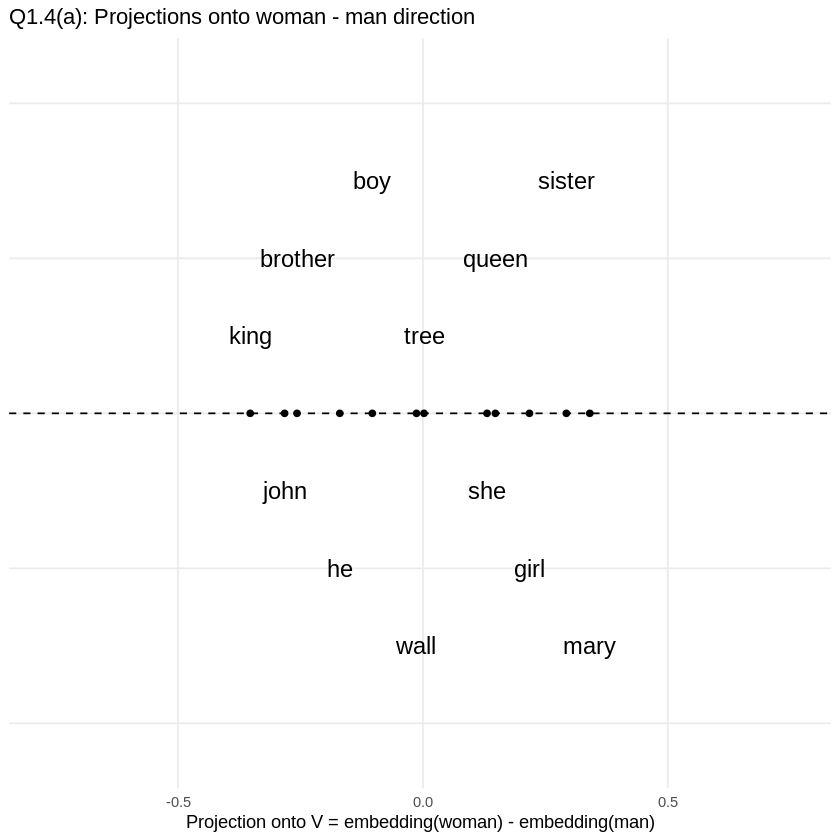

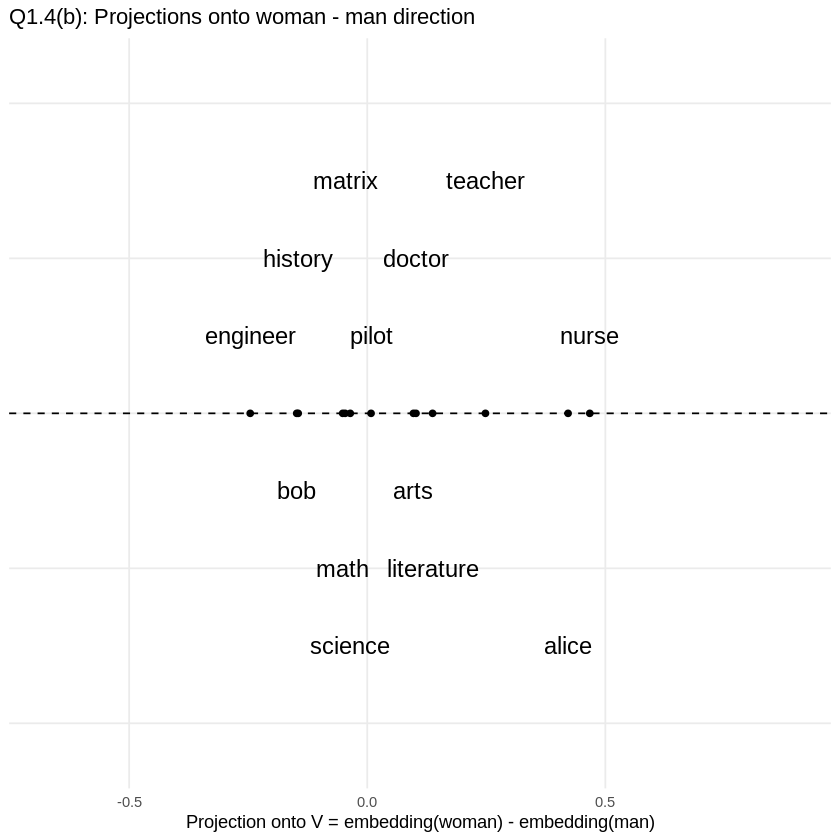

In [ ]:
# Q4
library(ggplot2)

# Data recheck
dict <- readLines("dictionary.txt")
svd_saved <- readRDS("svd_top100.rds")
V <- svd_saved$V   # 10000 x 100
print(dim(V))

# normalization & check
row_norms <- sqrt(rowSums(V^2))
row_norms[row_norms == 0] <- 1
V_norm <- V/row_norms
print(round(sqrt(rowSums(V_norm[1:5, ]^2)), 6))



# Helper functions
get_word_index <- function(word, dict) {
  idx <- match(word, dict)
  if (is.na(idx)) {
    stop(paste("Word not found in dictionary:", word))
  }
  return(idx)
}

get_embedding <- function(word, dict, V_norm) {
  idx <- get_word_index(word, dict)
  return(V_norm[idx, ])
}

projection_scalar <- function(x, u) {
  sum(x * u)/sqrt(sum(u^2))
}

compute_projections <- function(words, dict, V_norm, direction) {
  vals <- sapply(words, function(w) {
    emb <- get_embedding(w, dict, V_norm)
    projection_scalar(emb, direction)
  })

  data.frame(
    word = words,
    projection = vals,
    stringsAsFactors = FALSE
  )
}

plot_projection_line_gg <- function(df, title_text) {
  df <- df[order(df$projection), ]
  n <- nrow(df)

  x_pad <- max(0.15, 0.60 * diff(range(df$projection)))

  df$label_y <- rep(c(0.05, -0.05, 0.10, -0.10, 0.15, -0.15), length.out = n)

  ggplot(df, aes(x = projection, y = 0)) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    geom_point() +
    geom_text(aes(y = label_y, label = word), size = 5) +
    coord_cartesian(
      xlim = c(min(df$projection) - x_pad, max(df$projection) + x_pad),
      ylim = c(-0.22, 0.22)
    ) +
    labs(
      title = title_text,
      x = "Projection onto V = embedding(woman) - embedding(man)",
      y = NULL
    ) +
    theme_minimal() +
    theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      panel.grid.minor = element_blank()

    )


}


# V = V1 - V2
woman_emb <- get_embedding("woman", dict, V_norm)
man_emb   <- get_embedding("man", dict, V_norm)
gender_direction <- woman_emb - man_emb
print(sqrt(sum(gender_direction^2)))


# Q4a
words_a <- c("boy", "girl", "brother", "sister", "king", "queen",
             "he", "she", "john", "mary", "wall", "tree")

proj_a <- compute_projections(words_a, dict, V_norm, gender_direction)

cat("\nQ4a projections:\n")
print(proj_a[order(proj_a$projection), ])

plot_projection_line_gg(proj_a, "Q1.4(a): Projections onto woman - man direction")

# Q4b
words_b <- c("math", "matrix", "history", "nurse", "doctor", "pilot",
             "teacher", "engineer", "science", "arts", "literature",
             "bob", "alice")

proj_b <- compute_projections(words_b, dict, V_norm, gender_direction)


cat("\nQ4b projections:\n")
print(proj_b[order(proj_b$projection), ])

plot_projection_line_gg(proj_b, "Q1.4(b): Projections onto woman - man direction")

In [ ]:
# Q5
# cosine similarity
cosine_to_all <- function(vec, V_norm) {
  as.vector(V_norm %*% vec)
}

# k-10 nearby
nearest_words <- function(target_word, dict, V_norm, k = 10, exclude_self = TRUE) {
  idx <- match(target_word, dict)
  if (is.na(idx)) stop(paste("Word not found in dictionary:", target_word))

  target_vec <- V_norm[idx, ]
  target_vec
  sims <- cosine_to_all(target_vec, V_norm)

  if (exclude_self) {
    sims[idx] <- -Inf
  }

  top_idx <- order(sims, decreasing = TRUE)[1:k]

  data.frame(
    rank = 1:k,
    word = dict[top_idx],
    similarity = sims[top_idx],
    stringsAsFactors = FALSE
  )

}

# analogy solver
solve_analogy <- function(a, b, c, dict, V_norm, top_k = 5) {
  idx_a <- match(a, dict)
  idx_b <- match(b, dict)
  idx_c <- match(c, dict)

  if (any(is.na(c(idx_a, idx_b, idx_c)))) {
    return(NULL)
  }

  query_vec <- V_norm[idx_b, ] - V_norm[idx_a, ] + V_norm[idx_c, ]

  query_norm <- sqrt(sum(query_vec^2))
  if (query_norm == 0) return(NULL)
  query_vec <- query_vec/query_norm

  sims <- cosine_to_all(query_vec, V_norm)



  sims[c(idx_a, idx_b, idx_c)] <- -Inf

  top_idx <- order(sims, decreasing = TRUE)[1:top_k]

  list(
    predicted = dict[top_idx[1]],
    top_words = dict[top_idx],
    top_scores = sims[top_idx]
  )


}


# Q5a montreal
nn_montreal <- nearest_words("montreal", dict, V_norm, k = 10, exclude_self = TRUE)
print(nn_montreal)

# Q5b analogy
# file preprocessing
analogy_lines <- readLines("analogy_task.txt", warn = FALSE)
analogy_lines <- trimws(analogy_lines)
analogy_lines <- analogy_lines[analogy_lines != ""]
split_lines <- strsplit(analogy_lines, "\\s+")
split_lines <- split_lines[sapply(split_lines, length) == 4]

analogy_df <- data.frame(
  a = sapply(split_lines, `[`, 1),
  b = sapply(split_lines, `[`, 2),
  c = sapply(split_lines, `[`, 3),
  d = sapply(split_lines, `[`, 4),
  stringsAsFactors = FALSE
)

print(nrow(analogy_df))

# solve all analogies
predicted <- character(nrow(analogy_df))
correct_top1 <- logical(nrow(analogy_df))
in_top5 <- logical(nrow(analogy_df))
valid_row <- logical(nrow(analogy_df))

top5_list <- vector("list", nrow(analogy_df))

for (i in seq_len(nrow(analogy_df))) {
  a <- analogy_df$a[i]
  b <- analogy_df$b[i]
  c <- analogy_df$c[i]
  d <- analogy_df$d[i]


  ans <- solve_analogy(a, b, c, dict, V_norm, top_k = 5)

  predicted[i] <- ans$predicted
  correct_top1[i] <- (ans$predicted == d)
  in_top5[i] <- d %in% ans$top_words
  valid_row[i] <- TRUE
  top5_list[[i]] <- ans$top_words

}

analogy_df$predicted <- predicted
analogy_df$correct_top1 <- correct_top1
analogy_df$in_top5 <- in_top5
analogy_df$valid_row <- valid_row

# accuracy on valid rows
valid_df <- analogy_df[analogy_df$valid_row, ]


top1_acc <- mean(valid_df$correct_top1)
top5_acc <- mean(valid_df$in_top5)

cat("\nQ5.b: Analogy accuracy\n")
cat(sprintf("Top-1 accuracy: %.4f\n", top1_acc))
cat(sprintf("Top-5 accuracy: %.4f\n", top5_acc))


# difficult examples (correct guess not in top5)
difficult_df <- valid_df[(!valid_df$correct_top1) & (!valid_df$in_top5), ]
num_show <- min(3, nrow(difficult_df))


difficult_examples <- difficult_df[1:num_show, c("a", "b", "c", "d", "predicted")]
cat("\nTop 5 guesses for these examples:\n")
difficult_indices <- which(analogy_df$valid_row & (!analogy_df$correct_top1) & (!analogy_df$in_top5))[1:num_show]

for (j in seq_along(difficult_indices)) {
  idx <- difficult_indices[j]
  cat("\nExample", j, ":",
      analogy_df$a[idx], ":", analogy_df$b[idx], "::", analogy_df$c[idx], ":", analogy_df$d[idx], "\n")
  cat("Predicted:", analogy_df$predicted[idx], "\n")
  cat("Top 5 guesses:", paste(top5_list[[idx]], collapse = ", "), "\n")


}



   rank         word similarity
1     1      toronto  0.9246313
2     2    vancouver  0.8952179
3     3       ottawa  0.8802507
4     4     winnipeg  0.8486013
5     5      calgary  0.8434905
6     6 philadelphia  0.8404603
7     7      seattle  0.8300256
8     8     edmonton  0.8265117
9     9     portland  0.8231147
10   10       boston  0.8184821
[1] 5585

Q5.b: Analogy accuracy
Top-1 accuracy: 0.4474
Top-5 accuracy: 0.6765

Top 5 guesses for these examples:

Example 1 : athens : greece :: cairo : egypt 
Predicted: morocco 
Top 5 guesses: morocco, arabia, algeria, sudan, ethiopia 

Example 2 : athens : greece :: ottawa : canada 
Predicted: uganda 
Top 5 guesses: uganda, ghana, winnipeg, vancouver, africa 

Example 3 : athens : greece :: stockholm : sweden 
Predicted: belgium 
Top 5 guesses: belgium, finland, netherlands, switzerland, norway 


In [ ]:
# Q5c

# SVD process
transform_matrix <- function(C, method = c("raw", "sqrt", "log1p")) {
  method <- match.arg(method)

  if (method == "raw") {
    return(C)
  }

  if (method == "sqrt") {
    return(sqrt(C))
  }

  if (method == "log1p") {
    return(log1p(C))
  }
}


build_embeddings <- function(M, k) {
  svd_out <- irlba(M, nv = k, nu = k)
  V <- svd_out$v

  row_norms <- sqrt(rowSums(V^2))
  row_norms[row_norms == 0] <- 1
  V_norm <- V/row_norms

  return(V_norm)
}

# evaluator
evaluate_analogy <- function(dict, V_norm, top_k = 5) {

  predicted <- character(nrow(analogy_df))
  correct_top1 <- logical(nrow(analogy_df))
  in_top5 <- logical(nrow(analogy_df))
  valid_row <- logical(nrow(analogy_df))

  for (i in seq_len(nrow(analogy_df))) {
    a <- analogy_df$a[i]
    b <- analogy_df$b[i]
    c <- analogy_df$c[i]
    d <- analogy_df$d[i]

    ans <- solve_analogy(a, b, c, dict, V_norm, top_k = top_k)

    predicted[i] <- ans$predicted
    correct_top1[i] <- (ans$predicted == d)
    in_top5[i] <- d %in% ans$top_words
    valid_row[i] <- TRUE
  }

  analogy_df$predicted <- predicted
  analogy_df$correct_top1 <- correct_top1
  analogy_df$in_top5 <- in_top5
  analogy_df$valid_row <- valid_row

  # accuracy on valid rows
  valid_df <- analogy_df[analogy_df$valid_row, ]

  top1_acc <- mean(valid_df$correct_top1)
  top5_acc <- mean(valid_df$in_top5)

  cat(sprintf("Top-1 accuracy: %.4f\n", top1_acc))
  cat(sprintf("Top-5 accuracy: %.4f\n", top5_acc))

  return(list(
    analogy_df = analogy_df,
    valid_df = valid_df,
    top1_acc = top1_acc,
    top5_acc = top5_acc

  ))


}


In [ ]:
# Q5c run experiments

methods_to_try <- c("log1p", "raw", "sqrt")
k_values <- c(50, 100, 150)

results_list <- list()
counter <- 1

for (method in methods_to_try) {
  for (k in k_values) {
    cat("\n==============================\n")
    cat("Method:", method, "| k =", k, "\n")
    cat("==============================\n")

    M_trans <- transform_matrix(M, method = method)
    V_norm_new <- build_embeddings(M_trans, k = k)

    res <- evaluate_analogy(dict, V_norm_new, top_k = 5)

    results_list[[counter]] <- data.frame(
      method = method,
      k = k,
      top1_acc = res$top1_acc,
      top5_acc = res$top5_acc,
      stringsAsFactors = FALSE
    )
    print(results_list[[counter]])
    counter <- counter + 1

  }

}



Method: log1p | k = 50 
Top-1 accuracy: 0.4478
Top-5 accuracy: 0.6768
  method  k  top1_acc  top5_acc
1  log1p 50 0.4478066 0.6768129

Method: log1p | k = 100 
Top-1 accuracy: 0.5499
Top-5 accuracy: 0.7472
  method   k  top1_acc  top5_acc
1  log1p 100 0.5498657 0.7471799

Method: log1p | k = 150 
Top-1 accuracy: 0.5783
Top-5 accuracy: 0.7884
  method   k  top1_acc  top5_acc
1  log1p 150 0.5783348 0.7883617

Method: raw | k = 50 
Top-1 accuracy: 0.0485
Top-5 accuracy: 0.1307
  method  k   top1_acc  top5_acc
1    raw 50 0.04852283 0.1307073

Method: raw | k = 100 
Top-1 accuracy: 0.0748
Top-5 accuracy: 0.1859
  method   k   top1_acc top5_acc
1    raw 100 0.07484333 0.185855

Method: raw | k = 150 
Top-1 accuracy: 0.0947
Top-5 accuracy: 0.2143
  method   k   top1_acc  top5_acc
1    raw 150 0.09471799 0.2143241

Method: sqrt | k = 50 
Top-1 accuracy: 0.2600
Top-5 accuracy: 0.4759
  method  k  top1_acc  top5_acc
1   sqrt 50 0.2599821 0.4759176

Method: sqrt | k = 100 
Top-1 accuracy: 0.339